# ds006465 (3M-CPSEED) dataset audit

This notebook only reads BIDS metadata, event tables, and optionally one EDF header. It does **not** preprocess or overwrite EEG data. Run cells from top to bottom.

In [1]:
from pathlib import Path
import json
import re
import pandas as pd
from IPython.display import display

def locate_dataset(start: Path) -> Path:
    for parent in (start, *start.parents):
        candidate = parent / 'data' / 'ds006465'
        if candidate.exists():
            return candidate
    raise FileNotFoundError('Could not locate data/ds006465. Open this notebook inside eeg_to_voice_chinese.')

DATASET = locate_dataset(Path.cwd().resolve())
print(f'DATASET = {DATASET}')
print(json.loads((DATASET / 'dataset_description.json').read_text())['Name'])

DATASET = /Users/samxie/Research/EEG-Voice/ref_github/speech_decoding/eeg2wave_server_bundle/eeg_to_voice_chinese/data/ds006465
3M-CPSEED：An EEG-based Dataset for Chinese Pinyin Production in Overt, Silent-intended, and Imagined Speech


## 1. BIDS file inventory

The EDF paths may be git-annex symlinks, but listing them does not trigger a download.

In [2]:
edf_files = sorted(DATASET.glob('sub-*/ses-*/eeg/*_eeg.edf'))
event_files = sorted(DATASET.glob('sub-*/ses-*/eeg/*_events.tsv'))
channel_files = sorted(DATASET.glob('sub-*/ses-*/eeg/*_channels.tsv'))
sidecar_files = sorted(DATASET.glob('sub-*/ses-*/eeg/*_eeg.json'))
subjects = sorted({path.parts[-4] for path in event_files})
sessions = sorted({path.parts[-3] for path in event_files}, key=lambda x: int(x.split('-')[1]))

summary = pd.Series({
    'subjects': len(subjects),
    'sessions_per_subject': len(sessions),
    'raw EDF recordings': len(edf_files),
    'events.tsv files': len(event_files),
    'channels.tsv files': len(channel_files),
    'EEG sidecar JSON files': len(sidecar_files),
})
display(summary.to_frame('count'))
print('Subjects:', ', '.join(subjects))
print('Sessions:', ', '.join(sessions))

,count
subjects,20
sessions_per_subject,4
raw EDF recordings,80
events.tsv files,80
channels.tsv files,79
EEG sidecar JSON files,80


Subjects: sub-01, sub-02, sub-03, sub-04, sub-05, sub-06, sub-07, sub-08, sub-09, sub-10, sub-11, sub-12, sub-13, sub-14, sub-15, sub-16, sub-17, sub-18, sub-19, sub-20
Sessions: ses-1, ses-2, ses-3, ses-4


## 2. Trial and label audit from BIDS events

A row in `events.tsv` is treated as one labelled event/trial marker. This is the reproducible count for the BIDS raw layer.

In [3]:
event_frames = []
for path in event_files:
    match = re.search(r'(sub-\d+)/(ses-\d+)/eeg/', path.as_posix())
    frame = pd.read_csv(path, sep='\t')
    frame['subject'] = match.group(1)
    frame['session'] = match.group(2)
    frame['event_file'] = path.relative_to(DATASET).as_posix()
    event_frames.append(frame)

events = pd.concat(event_frames, ignore_index=True)
events['trial_type'] = events['trial_type'].astype(str)
label_counts = events['trial_type'].value_counts().sort_index(key=lambda s: s.astype(int))

print(f'BIDS event trials: {len(events):,}')
print(f'Distinct labels: {events.trial_type.nunique()}')
display(label_counts.rename_axis('label_code').to_frame('n_trials'))
display(events.groupby(['subject', 'session']).size().rename('n_trials').unstack(fill_value=0))

BIDS event trials: 4,000
Distinct labels: 10


,n_trials
label_code,
1,400
2,400
3,400
4,400
5,400
6,400
7,400
8,400
9,400


session,ses-1,ses-2,ses-3,ses-4
subject,,,,
sub-01,50,50,50,50
sub-02,50,50,50,50
sub-03,50,50,50,50
sub-04,50,50,50,50
sub-05,50,50,50,50
sub-06,50,50,50,50
sub-07,50,50,50,50
sub-08,50,50,50,50
sub-09,50,50,50,50


## 3. Pinyin label protocol

The README defines ten target sounds: four finals (`a`, `i`, `u`, `ü`) and six initials (`m`, `f`, `j`, `l`, `k`, `ch`). The BIDS `events.tsv` files store only codes `1`–`10`; this dataset copy does not document the code-to-Pinyin mapping. Do not assume the order below is verified until it is checked against the collection code/protocol.

In [4]:
candidate_protocol_order = ['a', 'i', 'u', 'ü', 'm', 'f', 'j', 'l', 'k', 'ch']
label_audit = pd.DataFrame({
    'event_code': sorted(events.trial_type.astype(int).unique()),
    'candidate_protocol_order__UNVERIFIED': candidate_protocol_order,
})
display(label_audit)
print('Action required before phoneme-level modelling: verify the event-code mapping independently.')

,event_code,candidate_protocol_order__UNVERIFIED
0,1,a
1,2,i
2,3,u
3,4,ü
4,5,m
5,6,f
6,7,j
7,8,l
8,9,k
9,10,ch


Action required before phoneme-level modelling: verify the event-code mapping independently.


## 4. Channel, sampling-rate, and recording-duration audit

In [5]:
channel_rows = []
for path in channel_files:
    match = re.search(r'(sub-\d+)/(ses-\d+)/eeg/', path.as_posix())
    channels = pd.read_csv(path, sep='\t')
    channel_rows.append({
        'subject': match.group(1), 'session': match.group(2),
        'n_channels': len(channels),
        'sampling_hz': channels['sampling_frequency'].dropna().unique().tolist(),
    })
channels_audit = pd.DataFrame(channel_rows)
display(channels_audit.groupby('n_channels').size().rename('recordings').to_frame())
display(channels_audit.explode('sampling_hz').groupby('sampling_hz').size().rename('recordings').to_frame())

sidecar_rows = []
for path in sidecar_files:
    match = re.search(r'(sub-\d+)/(ses-\d+)/eeg/', path.as_posix())
    meta = json.loads(path.read_text())
    sidecar_rows.append({
        'subject': match.group(1), 'session': match.group(2),
        'sampling_hz': meta.get('SamplingFrequency'),
        'duration_s': meta.get('RecordingDuration'),
        'eeg_channels': meta.get('EEGChannelCount'),
    })
sidecars = pd.DataFrame(sidecar_rows)
display(sidecars.describe(include='all'))

recording_keys = {(p.parts[-4], p.parts[-3]) for p in edf_files}
channel_keys = set(zip(channels_audit.subject, channels_audit.session))
print('Recordings without channels.tsv:', sorted(recording_keys - channel_keys))

,recordings
n_channels,
32,58
33,2
126,19


,recordings
sampling_hz,
200.0,2
500.0,77


,subject,session,sampling_hz,duration_s,eeg_channels
count,80,80,80.0,8.000000e+01,80.0
unique,20,4,NaN,NaN,NaN
top,sub-01,ses-1,NaN,NaN,NaN
freq,4,20,NaN,NaN,NaN
mean,NaN,NaN,500.0,1.628998e+03,32.0
std,NaN,NaN,0.0,2.288082e-13,0.0
min,NaN,NaN,500.0,1.628998e+03,32.0
25%,NaN,NaN,500.0,1.628998e+03,32.0
50%,NaN,NaN,500.0,1.628998e+03,32.0
75%,NaN,NaN,500.0,1.628998e+03,32.0


Recordings without channels.tsv: [('sub-03', 'ses-2')]


## 5. Optional: inspect a single EDF header

This reads only the header (`preload=False`) and leaves the raw signal unchanged.

In [6]:
import mne

example_edf = edf_files[0]
if not example_edf.exists():
    print(f'EDF content is unavailable locally: {example_edf}')
    print('Retrieve only this recording with: datalad get ' + str(example_edf.relative_to(DATASET)))
else:
    raw = mne.io.read_raw_edf(example_edf, preload=False, verbose='ERROR')
    display(pd.Series({
        'file': example_edf.relative_to(DATASET).as_posix(),
        'sampling_hz': raw.info['sfreq'],
        'channels': len(raw.ch_names),
        'duration_s': raw.times[-1],
        'channel_names': ', '.join(raw.ch_names[:12]) + (' ...' if len(raw.ch_names) > 12 else ''),
    }).to_frame('value'))

,value
file,sub-01/ses-1/eeg/sub-01_ses-1_task-imaginedspe...
sampling_hz,500.0
channels,33
duration_s,1628.998
channel_names,"P8, T8, CP6, FC6, F8, F4, C4, P4, AF4, Fp2, Fp..."


## 6. Derivative inventory and interpretation warnings

`derivatives/preproc` contains phase-specific MATLAB files (`speak`, `intend`, `imagine`). Keep it separate from raw BIDS EDF analyses until its variables and preprocessing provenance have been verified.

In [7]:
mat_files = sorted((DATASET / 'derivatives' / 'preproc').rglob('*.mat'))
def phase_of(path):
    name = path.name.lower()
    for phase in ('speak', 'intend', 'imagine'):
        if phase in name:
            return phase
    return 'other'

phase_counts = pd.Series([phase_of(path) for path in mat_files]).value_counts().rename_axis('phase').to_frame('n_mat_files')
display(phase_counts)

print('Key audit conclusion: raw BIDS events provide 4,000 labelled markers (20 subjects × 4 sessions × 50).')
print('The README statement of 1,600 trials per participant is not consistent with those raw event tables; resolve this before reporting a trial count beyond the BIDS marker count.')
print('The event files label codes 1–10, but do not identify whether a marker corresponds to speaking, silent articulation, or imagery.')

,n_mat_files
phase,
imagine,93
intend,93
speak,93


Key audit conclusion: raw BIDS events provide 4,000 labelled markers (20 subjects × 4 sessions × 50).
The README statement of 1,600 trials per participant is not consistent with those raw event tables; resolve this before reporting a trial count beyond the BIDS marker count.
The event files label codes 1–10, but do not identify whether a marker corresponds to speaking, silent articulation, or imagery.


## 7. EEG visualization (read-only)

This loads a short window around the first labelled event to show raw waveform, PSD, and all event onsets. It does not filter, preprocess, or save data.

Reading 0 ... 5000  =      0.000 ...    10.000 secs...
sub-01/ses-1/eeg/sub-01_ses-1_task-imaginedspeech_eeg.edf | 500.0 Hz | 33 channels | 4.05–14.05 s
Using matplotlib as 2D backend.


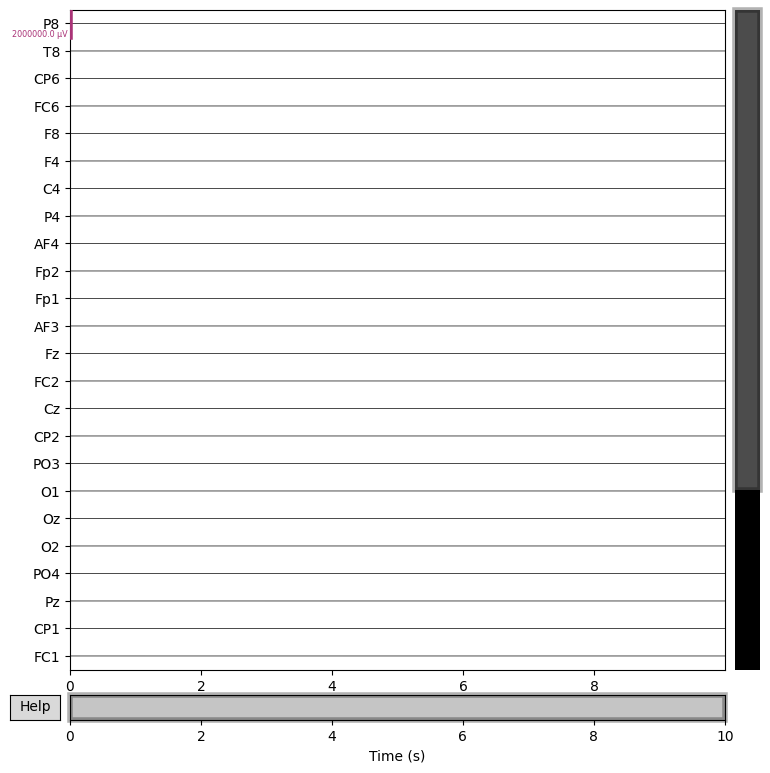

Effective window size : 4.096 (s)
Plotting power spectral density (dB=True).


/opt/anaconda3/envs/eegvoice/lib/python3.12/site-packages/mne/viz/utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


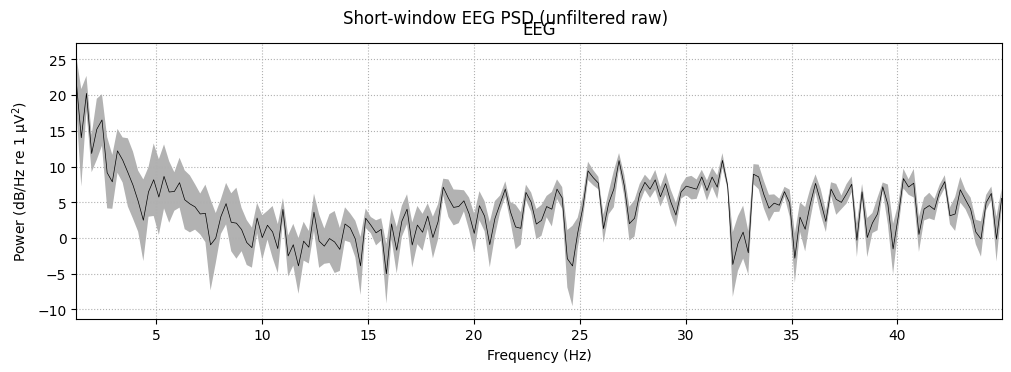

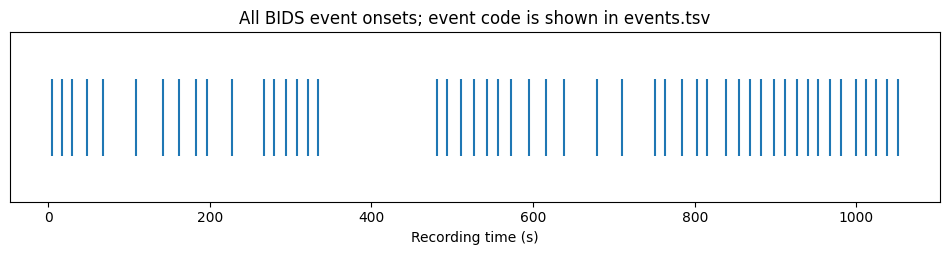

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import mne

PLOT_SUBJECT = 'sub-01'
PLOT_SESSION = 'ses-1'
PLOT_SECONDS = 10.0

plot_dir = DATASET / PLOT_SUBJECT / PLOT_SESSION / 'eeg'
plot_edf = next(plot_dir.glob('*_eeg.edf'))
plot_events = pd.read_csv(next(plot_dir.glob('*_events.tsv')), sep='\t')
raw_plot = mne.io.read_raw_edf(plot_edf, preload=False, verbose='ERROR')
first_onset = float(plot_events['onset'].iloc[0])
tmin = max(0.0, first_onset - 1.0)
tmax = min(tmin + PLOT_SECONDS, raw_plot.times[-1])
window = raw_plot.copy().crop(tmin=tmin, tmax=tmax).load_data()

print(f'{plot_edf.relative_to(DATASET)} | {window.info["sfreq"]} Hz | {len(window.ch_names)} channels | {tmin:.2f}–{tmax:.2f} s')
window.plot(duration=min(PLOT_SECONDS, tmax - tmin), n_channels=min(24, len(window.ch_names)), scalings='auto', show_scrollbars=True)

fig_psd = window.compute_psd(fmin=1, fmax=45).plot(average=True, spatial_colors=False)
fig_psd.suptitle('Short-window EEG PSD (unfiltered raw)', y=1.02)

fig, ax = plt.subplots(figsize=(12, 2.2))
ax.eventplot(plot_events['onset'], colors='tab:blue', lineoffsets=0, linelengths=0.8)
ax.set(xlabel='Recording time (s)', yticks=[], title='All BIDS event onsets; event code is shown in events.tsv')
plt.show()

## 8. Audio listener

3M-CPSEED contains EEG and phase-specific derivative MATLAB files, not recorded WAV/FLAC. This cell plays a real WAV/FLAC only after you add an explicitly labelled model output or canonical-TTS reference.

In [9]:
from IPython.display import Audio, display

audio_roots = [DATASET, DATASET.parent.parent / 'eeg_output' / 'audio_16k']
audio_files = sorted({path for root in audio_roots if root.exists() for ext in ('*.wav', '*.flac') for path in root.rglob(ext)})
if audio_files:
    selected_audio = audio_files[0]
    print('Playing:', selected_audio)
    display(Audio(filename=str(selected_audio)))
else:
    print('No WAV/FLAC found. Do not interpret a later canonical-TTS file as trial-recorded audio; name it by its source and rendering condition.')

No WAV/FLAC found. Do not interpret a later canonical-TTS file as trial-recorded audio; name it by its source and rendering condition.
